In [74]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import random

In [75]:
(
    x_train, 
    y_train
    ), (
        x_test, 
        y_test
        ) = keras.datasets.mnist.load_data()

In [76]:
type(x_train)

numpy.ndarray

In [77]:
x_train.shape

(60000, 28, 28)

In [78]:
x_test.shape

(10000, 28, 28)

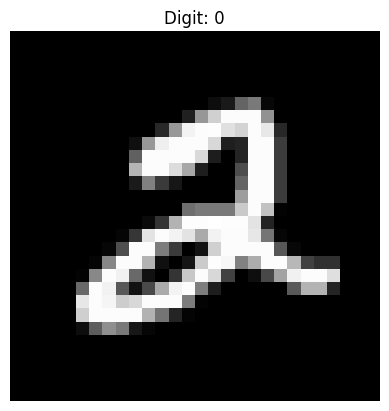

In [79]:
# Display the image
plt.imshow(x_train[5], cmap='gray')  # Use 'gray' colormap for grayscale images
plt.title(f"Digit: {y_train[1]}")
plt.axis('off')  # Hide axis
plt.show()

In [80]:
#x_train[1]

In [81]:
x_train[1].max()

np.uint8(255)

In [82]:
x_train[1].min()

np.uint8(0)

In [83]:
# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

In [84]:
x_train[1].max()

np.float64(1.0)

In [85]:
x_train[1].min()

np.float64(0.0)

In [86]:
x_train[1].shape

(28, 28)

In [87]:
x_train.shape

(60000, 28, 28)

In [88]:
# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [89]:
x_train[1].shape

(784,)

In [90]:
x_train.shape

(60000, 784)

In [91]:
from tensorflow import keras

# Define the ANN model
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),  # Explicit Input Layer
    keras.layers.Dense(128, activation='relu'),  # Hidden layer 1
    keras.layers.Dense(64, activation='relu'),  # Hidden layer 2
    keras.layers.Dense(32, activation='relu'),  # Hidden layer 3
    keras.layers.Dense(10, activation='softmax')  # Output layer (10 classes)
])


In [92]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [93]:
# Print model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
# Train the model
#model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

In [95]:
history = model.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8708 - loss: 0.4379 - val_accuracy: 0.9569 - val_loss: 0.1312
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9668 - loss: 0.1073 - val_accuracy: 0.9670 - val_loss: 0.1001
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9773 - loss: 0.0731 - val_accuracy: 0.9702 - val_loss: 0.0938
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9826 - loss: 0.0535 - val_accuracy: 0.9753 - val_loss: 0.0797
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9863 - loss: 0.0429 - val_accuracy: 0.9749 - val_loss: 0.0853
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9877 - loss: 0.0369 - val_accuracy: 0.9765 - val_loss: 0.0829
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9774 - val_loss: 0.0843
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9908 - loss: 0.0272 - 

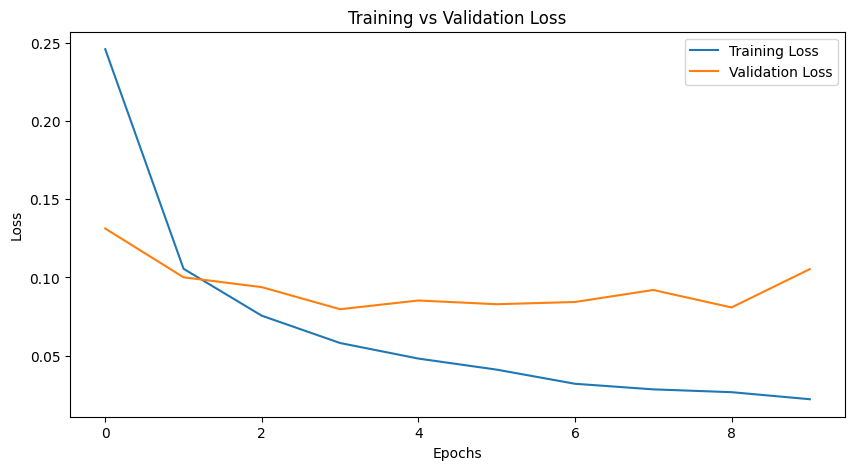

In [96]:
# Plot Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [97]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - accuracy: 0.9715 - loss: 0.1301
Test accuracy: 0.9755


In [98]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step


In [99]:
def plot_image(index):
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[index])}, Actual: {y_test[index]}")
    plt.axis('off')
    plt.show()

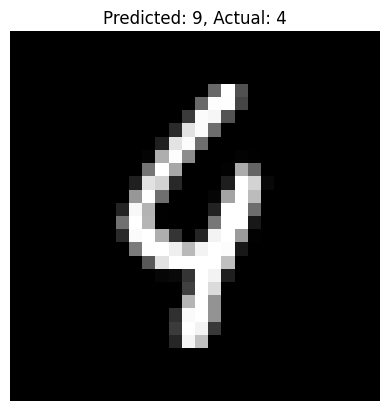

In [100]:
plot_image(115)  